# Calculus Refresher — Derivatives & Integrals for Quantitative Finance

Every pricing formula is either a derivative (a sensitivity) or an integral (an expected value under a measure). This notebook builds the calculus you need before touching Black-Scholes, duration, Greeks, or risk-neutral pricing.

**Roadmap**

1. Derivatives as rates of change — definition and geometry
2. Differentiation rules — power, product, quotient, chain
3. Partial derivatives and the gradient
4. Higher-order derivatives — Taylor expansion
5. Optimisation — unconstrained and Lagrange multipliers
6. Integration — area, antiderivatives, the Fundamental Theorem
7. Numerical differentiation and integration
8. Finance applications — Greeks, duration/convexity, option pricing as an integral

In [1]:
import math

import matplotlib.pyplot as plt
import numpy as np
import scipy.integrate as integrate
import scipy.stats as stats

rng = np.random.default_rng(42)

plt.rcParams.update(
    {
        "figure.figsize": (10, 4),
        "axes.spines.top": False,
        "axes.spines.right": False,
        "axes.grid": True,
        "grid.alpha": 0.3,
    }
)

np.set_printoptions(precision=6, suppress=True)

---
## 1  Derivatives as Rates of Change

### 1.1  The limit definition

The **derivative** of $f$ at $x$ is the instantaneous rate of change:

$$f'(x) = \frac{df}{dx} = \lim_{h \to 0} \frac{f(x+h) - f(x)}{h}$$

Geometrically, it is the slope of the **tangent line** at $(x, f(x))$ — the limit of secant slopes as $h \to 0$.

### 1.2  Financial interpretation

Every Greek is a derivative:

| Greek | Definition | Meaning |
|---|---|---|
| Delta $\Delta$ | $\partial V / \partial S$ | Change in option value per \$1 move in spot |
| Gamma $\Gamma$ | $\partial^2 V / \partial S^2$ | Rate of change of delta |
| Theta $\Theta$ | $\partial V / \partial t$ | Daily time decay |
| Vega $\mathcal{V}$ | $\partial V / \partial \sigma$ | Sensitivity to implied vol |
| Rho $\rho$ | $\partial V / \partial r$ | Sensitivity to interest rates |
| Duration $D$ | $-\frac{1}{P}\frac{\partial P}{\partial y}$ | % price change per 1 bp move in yield |

The differential $dV \approx \Delta\,dS$ is the foundation of **delta hedging**.

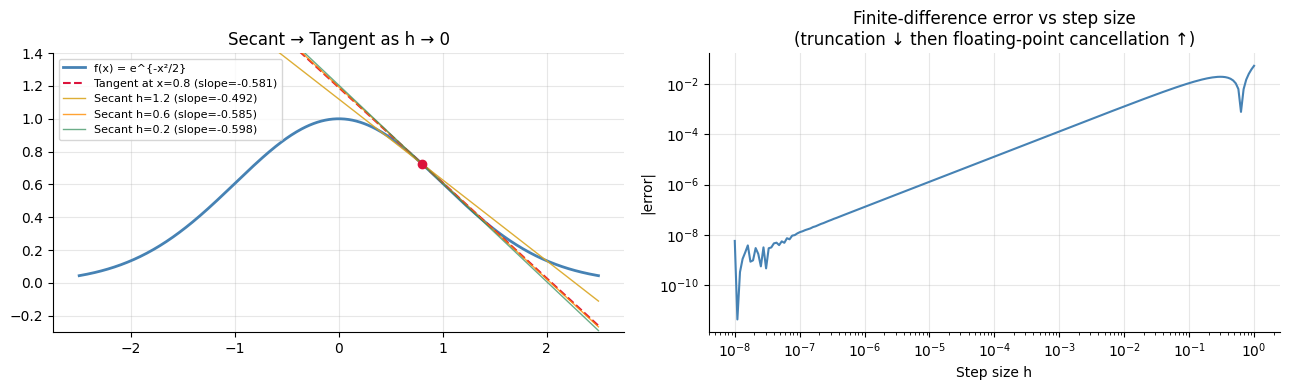

In [18]:
# Visualise the limit definition: secant → tangent as h → 0
def f(x: float | np.ndarray) -> float | np.ndarray:
    return np.exp(-0.5 * x**2)  # Gaussian kernel — appears in Black-Scholes


def f_prime_exact(x: float | np.ndarray) -> float | np.ndarray:
    return -x * np.exp(-0.5 * x**2)


x0 = 0.8
x_plot = np.linspace(-2.5, 2.5, 400)

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].plot(x_plot, f(x_plot), color="steelblue", linewidth=2, label="f(x) = e^{-x²/2}")
slope_exact = f_prime_exact(x0)
tangent = f(x0) + slope_exact * (x_plot - x0)
axes[0].plot(
    x_plot,
    tangent,
    "--",
    color="crimson",
    linewidth=1.5,
    label=f"Tangent at x={x0} (slope={slope_exact:.3f})",
)

for h, col, alpha in [(1.2, "goldenrod", 0.9), (0.6, "darkorange", 0.8), (0.2, "seagreen", 0.7)]:
    slope = (f(x0 + h) - f(x0)) / h
    secant = f(x0) + slope * (x_plot - x0)
    axes[0].plot(
        x_plot,
        secant,
        "-",
        color=col,
        linewidth=1,
        alpha=alpha,
        label=f"Secant h={h:.1f} (slope={slope:.3f})",
    )

axes[0].scatter([x0], [f(x0)], color="crimson", zorder=5)
axes[0].set_ylim(-0.3, 1.4)
axes[0].set_title("Secant → Tangent as h → 0")
axes[0].legend(fontsize=8)

# Error in finite-difference approximation vs h
h_vals = np.logspace(-8, 0, 200)
errors = [abs((f(x0 + h) - f(x0)) / h - f_prime_exact(x0)) for h in h_vals]

axes[1].loglog(h_vals, errors, color="steelblue")
axes[1].set_xlabel("Step size h")
axes[1].set_ylabel("|error|")
axes[1].set_title(
    "Finite-difference error vs step size\n(truncation ↓ then floating-point cancellation ↑)"
)

plt.tight_layout()
plt.show()

---
## 2  Differentiation Rules

### 2.1  Core rules

| Rule | Formula | Example |
|---|---|---|
| Power | $(x^n)' = n x^{n-1}$ | $(x^3)' = 3x^2$ |
| Sum | $(f+g)' = f' + g'$ | Linearity |
| Product | $(fg)' = f'g + fg'$ | $(x e^x)' = e^x + xe^x$ |
| Quotient | $(f/g)' = (f'g - fg')/g^2$ | — |
| Exponential | $(e^x)' = e^x$, $(a^x)' = a^x \ln a$ | — |
| Logarithm | $(\ln x)' = 1/x$ | Central in log-return calculus |

### 2.2  The Chain Rule — the workhorse

If $y = f(g(x))$, then:

$$\frac{dy}{dx} = \frac{df}{dg} \cdot \frac{dg}{dx} = f'(g(x)) \cdot g'(x)$$

In Leibniz notation (how to remember it — the intermediate variable cancels):

$$\frac{dy}{dx} = \frac{dy}{du} \cdot \frac{du}{dx}$$

**Finance examples:**
- If $V = V(S)$ and $S = S(t)$: $\frac{dV}{dt} = \frac{dV}{dS} \cdot \frac{dS}{dt} = \Delta \cdot \frac{dS}{dt}$
- $\frac{d}{dS}\ln S = \frac{1}{S}$ (log-return sensitivity to price)
- $\frac{d}{d\sigma} N(d_1(\sigma)) = N'(d_1) \cdot \frac{\partial d_1}{\partial \sigma}$ (vega computation)

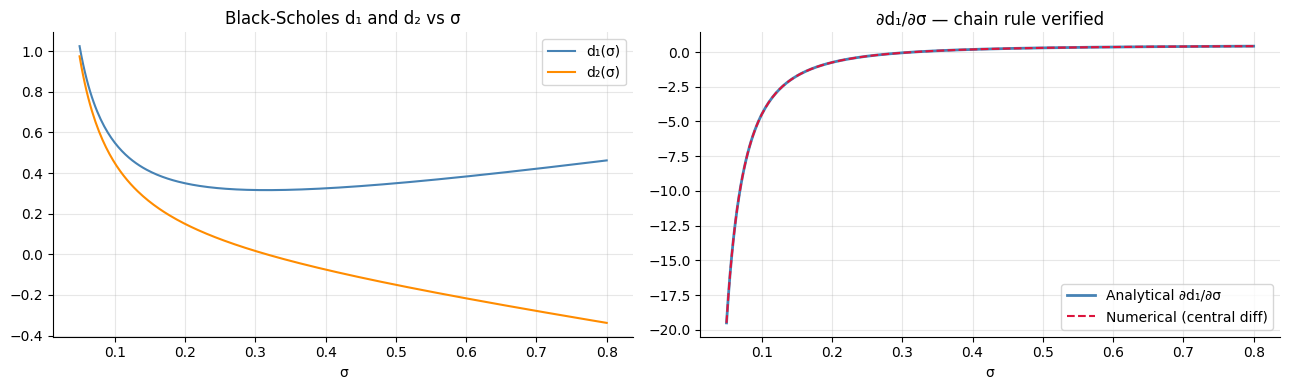

Max error between analytical and numerical: 8.00e-07


In [19]:
# Chain rule in action: d/dσ of the Black-Scholes d₁ term
# d₁ = [ln(S/K) + (r + σ²/2)T] / (σ√T)
# We'll compute ∂d₁/∂σ analytically and verify numerically

S, K, r, T = 100.0, 100.0, 0.05, 1.0


def d1(sigma: float) -> float:
    return (math.log(S / K) + (r + 0.5 * sigma**2) * T) / (sigma * math.sqrt(T))


def d2(sigma: float) -> float:
    return d1(sigma) - sigma * math.sqrt(T)


# Analytical ∂d₁/∂σ (chain rule + quotient rule)
def d1_dsigma(sigma: float) -> float:
    # d₁ = [ln(S/K)/σ + (r/σ + σ/2)√T]
    # ∂d₁/∂σ = -ln(S/K)/(σ²√T) + √T/2 ... simplifies to:
    return -d1(sigma) / sigma + math.sqrt(T)


sigma_vals = np.linspace(0.05, 0.80, 300)
d1_vals = np.array([d1(s) for s in sigma_vals])
analytical_deriv = np.array([d1_dsigma(s) for s in sigma_vals])

# Numerical derivative (central difference)
h = 1e-5
numerical_deriv = np.array([(d1(s + h) - d1(s - h)) / (2 * h) for s in sigma_vals])

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
axes[0].plot(sigma_vals, d1_vals, color="steelblue", label="d₁(σ)")
axes[0].plot(sigma_vals, [d2(s) for s in sigma_vals], color="darkorange", label="d₂(σ)")
axes[0].set_xlabel("σ")
axes[0].set_title("Black-Scholes d₁ and d₂ vs σ")
axes[0].legend()

axes[1].plot(
    sigma_vals, analytical_deriv, color="steelblue", linewidth=2, label="Analytical ∂d₁/∂σ"
)
axes[1].plot(
    sigma_vals,
    numerical_deriv,
    "--",
    color="crimson",
    linewidth=1.5,
    label="Numerical (central diff)",
)
axes[1].set_xlabel("σ")
axes[1].set_title("∂d₁/∂σ — chain rule verified")
axes[1].legend()

plt.tight_layout()
plt.show()

print(
    f"Max error between analytical and numerical: {np.abs(analytical_deriv - numerical_deriv).max():.2e}"
)

---
## 3  Partial Derivatives and the Gradient

For $f : \mathbb{R}^n \to \mathbb{R}$, the **partial derivative** $\partial f / \partial x_i$ treats all other variables as constants.

The **gradient** collects all partials into a vector pointing in the direction of steepest ascent:

$$\nabla f(\mathbf{x}) = \left[\frac{\partial f}{\partial x_1}, \frac{\partial f}{\partial x_2}, \ldots, \frac{\partial f}{\partial x_n}\right]^\top$$

The **Hessian** $H_f(\mathbf{x})$ collects second partials — it governs curvature:

$$H_{ij} = \frac{\partial^2 f}{\partial x_i \partial x_j}$$

**Finance use:**
- Gradient of portfolio variance $\nabla_{\mathbf{w}}(\mathbf{w}^\top \Sigma \mathbf{w}) = 2\Sigma \mathbf{w}$ — drives optimisation
- The Hessian of a call price w.r.t. $(S, \sigma, r, t)$ gives the full Greeks matrix
- Total differential: $dV = \Delta\,dS + \mathcal{V}\,d\sigma + \rho\,dr + \Theta\,dt$ — the **P&L attribution identity**

In [20]:
# Gradient of portfolio variance w.r.t. weights
# f(w) = w^T Σ w  →  ∇_w f = 2Σw  (marginal variance contribution)
Sigma = np.array(
    [
        [0.04, 0.012, -0.003],
        [0.012, 0.01, 0.003],
        [-0.003, 0.003, 0.0225],
    ]
)
w = np.array([0.40, 0.35, 0.25])

grad_var = 2 * Sigma @ w  # analytical gradient
port_var = w @ Sigma @ w

# Marginal contribution to variance (MCV): w_i * (∂σ²_p/∂w_i)
mcv = w * grad_var
# MCV / total variance = % contribution from each asset
risk_contribution = mcv / port_var

print(f"Portfolio variance:       {port_var:.6f}  (σ_p = {math.sqrt(port_var):.2%})")
print(f"Gradient ∇_w σ²_p:        {grad_var}")
print()
asset_names = ["Equity", "Bonds", "Alternatives"]
print(f"{'Asset':>14}  {'Weight':>8}  {'MCV':>10}  {'Risk contrib'}")
for name, wi, rc in zip(asset_names, w, risk_contribution):
    print(f"{name:>14}  {wi:>8.0%}  {wi * 2 * (Sigma @ w)[0]:.2e}    {rc:.1%}")
print(f"{'Total':>14}  {w.sum():>8.0%}             {risk_contribution.sum():.1%}")

Portfolio variance:       0.012316  (σ_p = 11.10%)
Gradient ∇_w σ²_p:        [0.0389  0.0181  0.01095]

         Asset    Weight         MCV  Risk contrib
        Equity       40%  1.56e-02    126.3%
         Bonds       35%  1.36e-02    51.4%
  Alternatives       25%  9.73e-03    22.2%
         Total      100%             200.0%


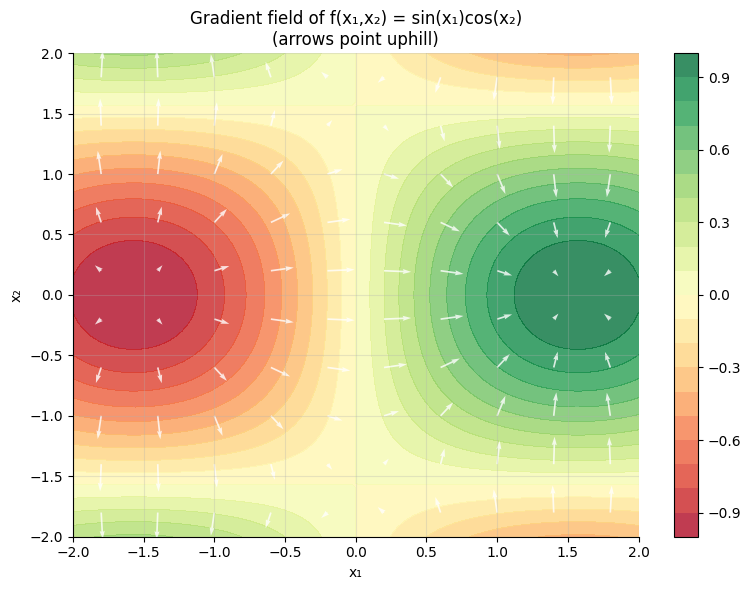

In [21]:
# Visualise the gradient as direction of steepest ascent on a 2D surface
x1 = np.linspace(-2, 2, 100)
x2 = np.linspace(-2, 2, 100)
X1, X2 = np.meshgrid(x1, x2)

# f(x1, x2) = sin(x1) * cos(x2) — arbitrary but illustrative
Z = np.sin(X1) * np.cos(X2)
# Gradient: [cos(x1)*cos(x2), -sin(x1)*sin(x2)]

fig, ax = plt.subplots(figsize=(8, 6))
cf = ax.contourf(X1, X2, Z, levels=20, cmap="RdYlGn", alpha=0.8)
plt.colorbar(cf, ax=ax)

# Draw gradient arrows on a coarser grid
x1g, x2g = np.meshgrid(np.linspace(-1.8, 1.8, 10), np.linspace(-1.8, 1.8, 10))
g1 = np.cos(x1g) * np.cos(x2g)
g2 = -np.sin(x1g) * np.sin(x2g)
ax.quiver(x1g, x2g, g1, g2, color="white", scale=20, width=0.003, alpha=0.8)

ax.set_title("Gradient field of f(x₁,x₂) = sin(x₁)cos(x₂)\n(arrows point uphill)")
ax.set_xlabel("x₁")
ax.set_ylabel("x₂")
plt.tight_layout()
plt.show()

---
## 4  Higher-Order Derivatives and Taylor Expansion

### 4.1  Taylor series

Any smooth function can be approximated near a point $a$ by its Taylor expansion:

$$f(x) = f(a) + f'(a)(x-a) + \frac{f''(a)}{2!}(x-a)^2 + \frac{f'''(a)}{3!}(x-a)^3 + \cdots$$

Truncating to first order gives a **linear** (tangent) approximation; to second order gives a **quadratic** (parabola) approximation.

### 4.2  Finance: Delta-Gamma approximation

For a small move $\delta S$ in the underlying:

$$\delta V \approx \underbrace{\Delta \cdot \delta S}_{\text{Delta P\&L}} + \underbrace{\frac{1}{2}\Gamma (\delta S)^2}_{\text{Gamma P\&L}} + \underbrace{\Theta \cdot \delta t}_{\text{time decay}}$$

The Gamma term is the second-order correction — it matters for large moves and explains why a delta-hedged long option position profits from volatility (long gamma = long convexity).

### 4.3  Bond duration and convexity

For a bond with price $P(y)$:

$$\frac{\delta P}{P} \approx -D_{\text{mod}} \cdot \delta y + \frac{1}{2} C \cdot (\delta y)^2$$

where $D_{\text{mod}} = -\frac{1}{P}\frac{dP}{dy}$ is **modified duration** and $C = \frac{1}{P}\frac{d^2P}{dy^2}$ is **convexity** — both are Taylor coefficients.

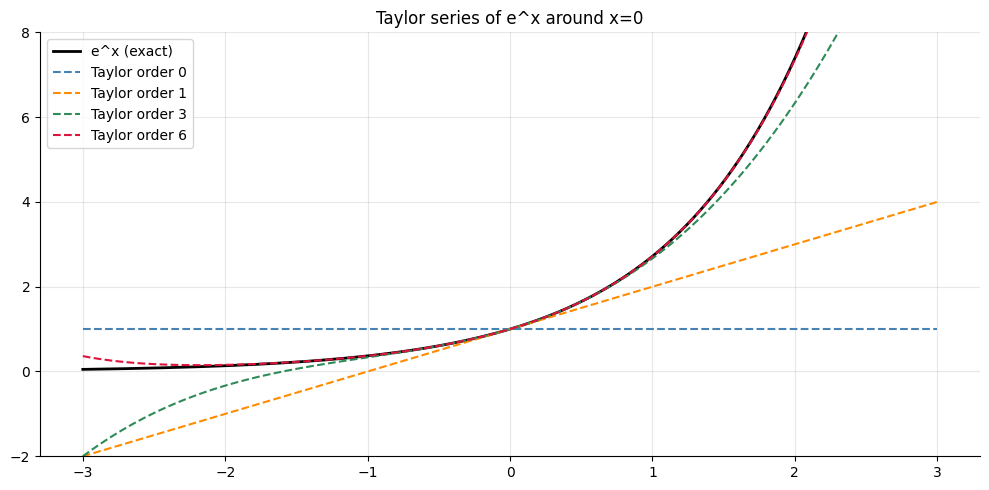

In [22]:
# Taylor approximation of e^x — building intuition
def taylor_exp(x: np.ndarray, n_terms: int) -> np.ndarray:
    result = np.zeros_like(x, dtype=float)
    for k in range(n_terms):
        result += x**k / math.factorial(k)
    return result


x = np.linspace(-3, 3, 400)
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(x, np.exp(x), color="black", linewidth=2, label="e^x (exact)")
colors = ["steelblue", "darkorange", "seagreen", "crimson"]
for terms, col in zip([1, 2, 4, 7], colors):
    ax.plot(
        x, taylor_exp(x, terms), "--", color=col, linewidth=1.5, label=f"Taylor order {terms - 1}"
    )
ax.set_ylim(-2, 8)
ax.set_title("Taylor series of e^x around x=0")
ax.legend()
plt.tight_layout()
plt.show()

Bond: 10Y, 5% coupon, yield = 5%
  Price P₀           = 6525.2193
  Modified Duration  = 9.2476 years
  Convexity          = 95.9764


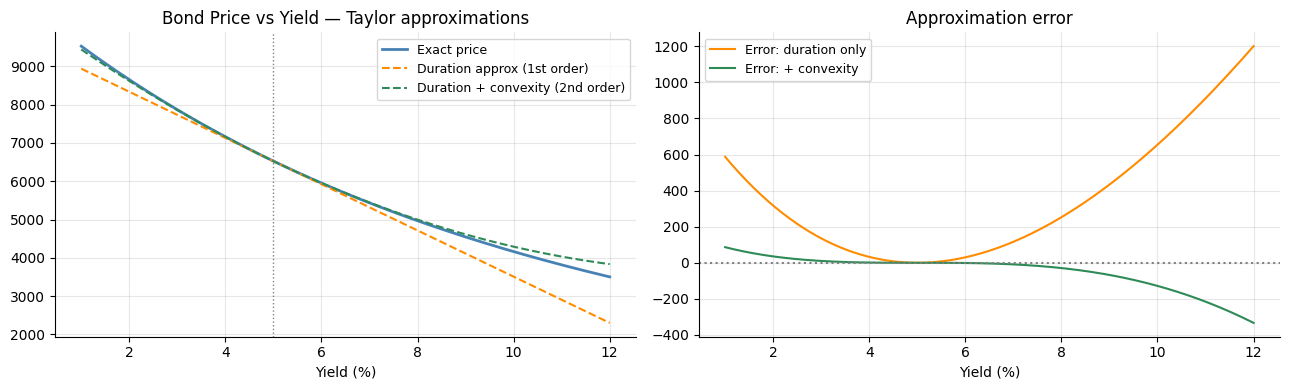

In [23]:
# Bond price and its Taylor approximation (duration + convexity)
# Coupon bond: P(y) = Σ C/(1+y)^t + Face/(1+y)^T
face = 1000.0
coupon_rate = 0.05
T_bond = 10  # years
coupon = face * coupon_rate


def bond_price(y: float | np.ndarray) -> float | np.ndarray:
    scalar = np.isscalar(y)
    y = np.atleast_1d(np.asarray(y, dtype=float))
    t = np.arange(1, T_bond + 1)
    pv_coupons = np.array([coupon / (1 + yi) ** t + face / (1 + yi) ** T_bond for yi in y]).sum(
        axis=1
    )
    return float(pv_coupons[0]) if scalar else pv_coupons


y0 = 0.05  # current yield = par yield
P0 = bond_price(y0)
h = 1e-5

# Numerical first and second derivatives
dP_dy = (bond_price(y0 + h) - bond_price(y0 - h)) / (2 * h)
d2P_dy2 = (bond_price(y0 + h) - 2 * P0 + bond_price(y0 - h)) / h**2

D_mod = -dP_dy / P0  # modified duration
convexity = d2P_dy2 / P0  # convexity

print(f"Bond: {T_bond}Y, {coupon_rate:.0%} coupon, yield = {y0:.0%}")
print(f"  Price P₀           = {P0:.4f}")
print(f"  Modified Duration  = {D_mod:.4f} years")
print(f"  Convexity          = {convexity:.4f}")

y_range = np.linspace(0.01, 0.12, 300)
P_exact = bond_price(y_range)

dy = y_range - y0
P_duration = P0 * (1 - D_mod * dy)  # first-order Taylor
P_convexity = P0 * (1 - D_mod * dy + 0.5 * convexity * dy**2)  # second-order Taylor

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
axes[0].plot(y_range * 100, P_exact, color="steelblue", linewidth=2, label="Exact price")
axes[0].plot(
    y_range * 100, P_duration, "--", color="darkorange", label="Duration approx (1st order)"
)
axes[0].plot(
    y_range * 100, P_convexity, "--", color="seagreen", label="Duration + convexity (2nd order)"
)
axes[0].axvline(y0 * 100, color="grey", linestyle=":", linewidth=1)
axes[0].set_xlabel("Yield (%)")
axes[0].set_title("Bond Price vs Yield — Taylor approximations")
axes[0].legend(fontsize=9)

axes[1].plot(y_range * 100, P_exact - P_duration, color="darkorange", label="Error: duration only")
axes[1].plot(y_range * 100, P_exact - P_convexity, color="seagreen", label="Error: + convexity")
axes[1].axhline(0, color="grey", linestyle=":")
axes[1].set_xlabel("Yield (%)")
axes[1].set_title("Approximation error")
axes[1].legend(fontsize=9)

plt.tight_layout()
plt.show()

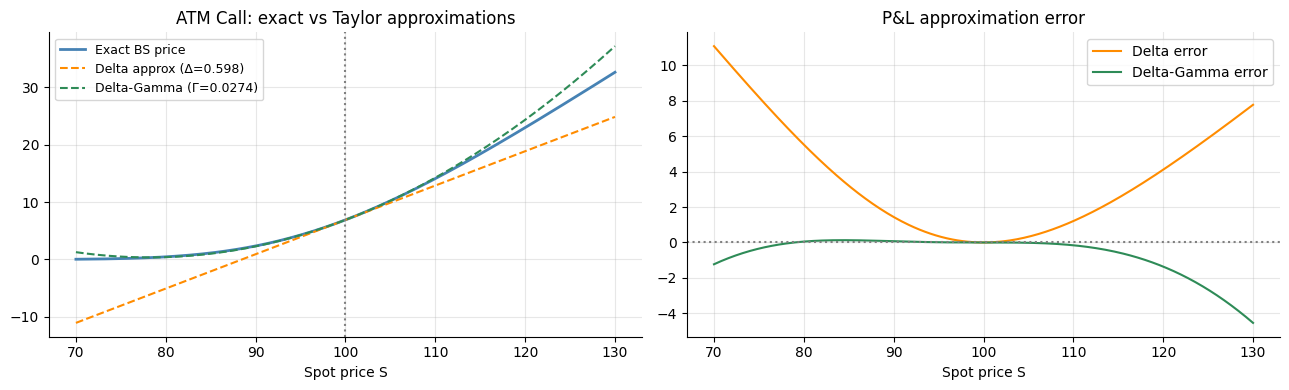

At dS=+20: exact ΔV = 16.2206  delta-gamma = 17.4264


In [24]:
# Delta-Gamma option P&L approximation
# We'll use Black-Scholes Greeks computed analytically (derived fully in section 8)
def bs_call(S: float, K: float, r: float, sigma: float, T: float) -> float:
    d_1 = (math.log(S / K) + (r + 0.5 * sigma**2) * T) / (sigma * math.sqrt(T))
    d_2 = d_1 - sigma * math.sqrt(T)
    return S * stats.norm.cdf(d_1) - K * math.exp(-r * T) * stats.norm.cdf(d_2)


def bs_delta(S: float, K: float, r: float, sigma: float, T: float) -> float:
    d_1 = (math.log(S / K) + (r + 0.5 * sigma**2) * T) / (sigma * math.sqrt(T))
    return stats.norm.cdf(d_1)


def bs_gamma(S: float, K: float, r: float, sigma: float, T: float) -> float:
    d_1 = (math.log(S / K) + (r + 0.5 * sigma**2) * T) / (sigma * math.sqrt(T))
    return stats.norm.pdf(d_1) / (S * sigma * math.sqrt(T))


S0, K, r, sigma, T_opt = 100.0, 100.0, 0.05, 0.20, 0.5  # ATM call

V0 = bs_call(S0, K, r, sigma, T_opt)
delta = bs_delta(S0, K, r, sigma, T_opt)
gamma = bs_gamma(S0, K, r, sigma, T_opt)

dS_range = np.linspace(-30, 30, 300)
S_new = S0 + dS_range

V_exact = np.array([bs_call(s, K, r, sigma, T_opt) for s in S_new])
V_delta = V0 + delta * dS_range  # first order
V_dg = V0 + delta * dS_range + 0.5 * gamma * dS_range**2  # second order

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
axes[0].plot(S_new, V_exact, color="steelblue", linewidth=2, label="Exact BS price")
axes[0].plot(
    S_new, V_delta, "--", color="darkorange", linewidth=1.5, label=f"Delta approx (Δ={delta:.3f})"
)
axes[0].plot(
    S_new, V_dg, "--", color="seagreen", linewidth=1.5, label=f"Delta-Gamma (Γ={gamma:.4f})"
)
axes[0].axvline(S0, color="grey", linestyle=":")
axes[0].set_xlabel("Spot price S")
axes[0].set_title("ATM Call: exact vs Taylor approximations")
axes[0].legend(fontsize=9)

axes[1].plot(S_new, V_exact - V_delta, color="darkorange", label="Delta error")
axes[1].plot(S_new, V_exact - V_dg, color="seagreen", label="Delta-Gamma error")
axes[1].axhline(0, color="grey", linestyle=":")
axes[1].set_xlabel("Spot price S")
axes[1].set_title("P&L approximation error")
axes[1].legend()

plt.tight_layout()
plt.show()

print(
    f"At dS=+20: exact ΔV = {V_exact[dS_range.searchsorted(20)] - V0:.4f}  "
    f"delta-gamma = {delta * 20 + 0.5 * gamma * 400:.4f}"
)

---
## 5  Optimisation

### 5.1  Unconstrained optimisation

At a local minimum, necessary conditions:
1. **First-order condition (FOC):** $\nabla f(\mathbf{x}^*) = \mathbf{0}$ (flat gradient)
2. **Second-order condition (SOC):** $H_f(\mathbf{x}^*)$ is positive semi-definite (bowl-shaped)

**Gradient descent** iterates: $\mathbf{x}_{t+1} = \mathbf{x}_t - \alpha \nabla f(\mathbf{x}_t)$

### 5.2  Constrained optimisation — Lagrange multipliers

Minimise $f(\mathbf{x})$ subject to $g(\mathbf{x}) = 0$. Form the **Lagrangian**:

$$\mathcal{L}(\mathbf{x}, \lambda) = f(\mathbf{x}) - \lambda\, g(\mathbf{x})$$

At the optimum: $\nabla_\mathbf{x} \mathcal{L} = 0$ and $\partial \mathcal{L}/\partial \lambda = 0$.

**Portfolio example:** minimise $\mathbf{w}^\top \Sigma \mathbf{w}$ subject to $\mathbf{1}^\top \mathbf{w} = 1$ gives the minimum-variance portfolio via the Lagrangian $\mathcal{L} = \mathbf{w}^\top\Sigma\mathbf{w} - \lambda(\mathbf{1}^\top\mathbf{w}-1)$. FOC: $2\Sigma\mathbf{w} = \lambda\mathbf{1}$ → $\mathbf{w}^* = \frac{\Sigma^{-1}\mathbf{1}}{\mathbf{1}^\top\Sigma^{-1}\mathbf{1}}$.

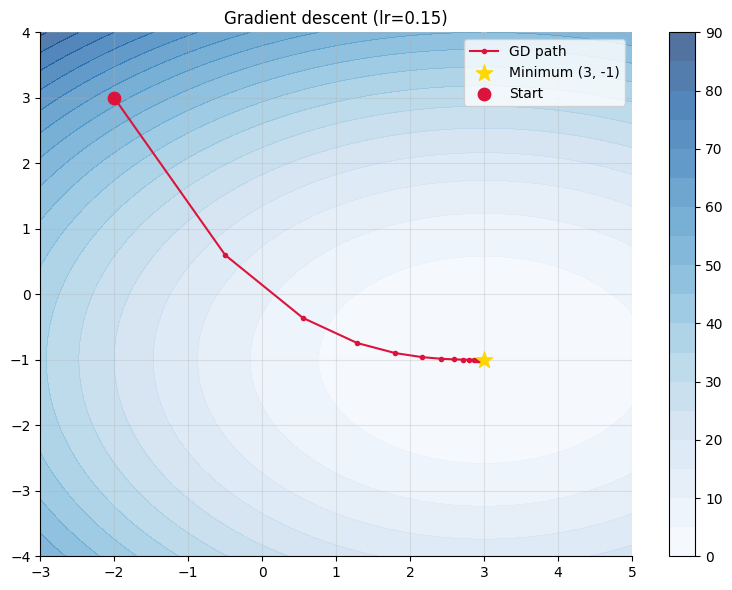

Converged to: (3.000000, -1.000000)  (exact: (3, -1))


In [25]:
# Gradient descent from scratch: minimise a simple quadratic loss
# f(x) = (x-3)^2 + 2(y+1)^2  →  minimum at (3, -1)


def f_quad(xy: np.ndarray) -> float:
    return (xy[0] - 3) ** 2 + 2 * (xy[1] + 1) ** 2


def grad_quad(xy: np.ndarray) -> np.ndarray:
    return np.array([2 * (xy[0] - 3), 4 * (xy[1] + 1)])


# Gradient descent
lr = 0.15
xy = np.array([-2.0, 3.0])  # starting point
path = [xy.copy()]

for _ in range(50):
    xy = xy - lr * grad_quad(xy)
    path.append(xy.copy())

path = np.array(path)

# Contour plot + descent path
x1g = np.linspace(-3, 5, 200)
x2g = np.linspace(-4, 4, 200)
X1g, X2g = np.meshgrid(x1g, x2g)
Zg = (X1g - 3) ** 2 + 2 * (X2g + 1) ** 2

fig, ax = plt.subplots(figsize=(8, 6))
cf = ax.contourf(X1g, X2g, Zg, levels=20, cmap="Blues", alpha=0.7)
plt.colorbar(cf, ax=ax)
ax.plot(path[:, 0], path[:, 1], "o-", color="crimson", markersize=3, linewidth=1.5, label="GD path")
ax.scatter([3], [-1], color="gold", s=150, zorder=5, marker="*", label="Minimum (3, -1)")
ax.scatter([path[0, 0]], [path[0, 1]], color="crimson", s=80, zorder=5, label="Start")
ax.set_title(f"Gradient descent (lr={lr})")
ax.legend()
plt.tight_layout()
plt.show()

print(f"Converged to: ({path[-1, 0]:.6f}, {path[-1, 1]:.6f})  (exact: (3, -1))")

In [26]:
# Lagrange multiplier: minimum variance portfolio
# Solve analytically and verify the FOC: 2Σw* = λ·1

import numpy.linalg as la

ones = np.ones(3)
Sigma_inv = la.inv(Sigma)

w_mv = Sigma_inv @ ones / (ones @ Sigma_inv @ ones)
lambda_mv = 2 / (ones @ Sigma_inv @ ones)  # Lagrange multiplier at optimum

# Verify FOC: 2Σw* = λ·1
lhs = 2 * Sigma @ w_mv
rhs = lambda_mv * ones

print("Lagrange FOC check: 2Σw* = λ·1")
print(f"  LHS: {lhs}")
print(f"  RHS: {rhs}")
print(f"  Max error: {np.abs(lhs - rhs).max():.2e}")
print()
print(f"Minimum variance portfolio weights: {w_mv}")
print(f"  σ_mv = {math.sqrt(w_mv @ Sigma @ w_mv):.2%}")
print(f"  λ (Lagrange multiplier) = {lambda_mv:.6f}")

Lagrange FOC check: 2Σw* = λ·1
  LHS: [0.016301 0.016301 0.016301]
  RHS: [0.016301 0.016301 0.016301]
  Max error: 6.94e-18

Minimum variance portfolio weights: [0.0048 0.7296 0.2656]
  σ_mv = 9.03%
  λ (Lagrange multiplier) = 0.016301


---
## 6  Integration

### 6.1  The definite integral

$$\int_a^b f(x)\,dx = \lim_{n \to \infty} \sum_{i=1}^n f(x_i^*) \Delta x$$

Geometrically: the signed area between $f$ and the $x$-axis on $[a, b]$.

### 6.2  The Fundamental Theorem of Calculus

If $F'(x) = f(x)$, then:

$$\int_a^b f(x)\,dx = F(b) - F(a)$$

This connects differentiation and integration: they are inverse operations.

### 6.3  Finance: expected values are integrals

$$E[X] = \int_{-\infty}^{\infty} x\,f(x)\,dx$$

**Option pricing** is an expected value under the risk-neutral measure $\mathbb{Q}$:

$$C = e^{-rT} E^\mathbb{Q}[\max(S_T - K, 0)] = e^{-rT} \int_K^{\infty} (S_T - K)\,f^\mathbb{Q}(S_T)\,dS_T$$

where $f^\mathbb{Q}$ is the risk-neutral density of $S_T$. **The Black-Scholes formula is this integral evaluated in closed form** when $S_T$ is log-normally distributed.

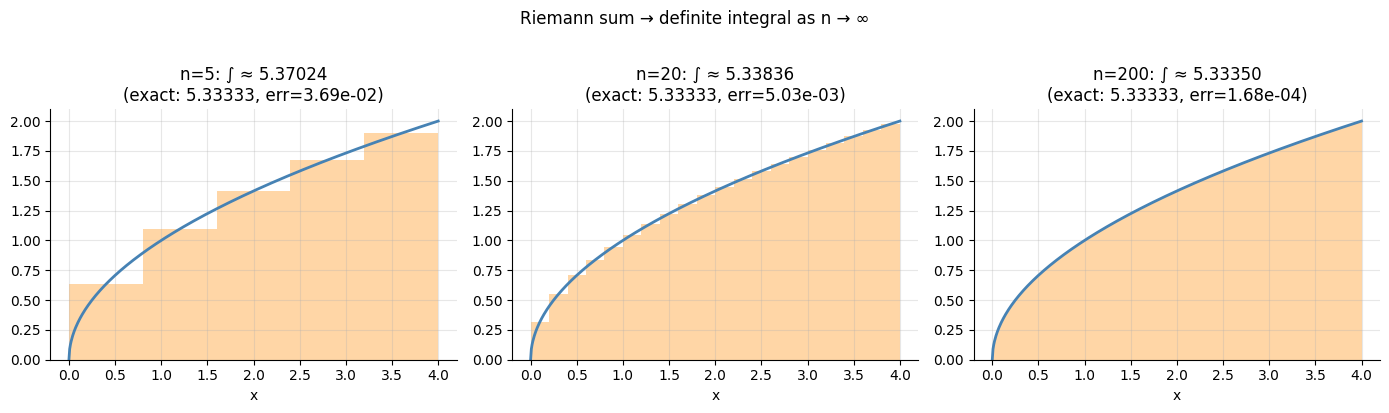

In [27]:
# Riemann sum converging to the integral — build geometric intuition
def g(x: np.ndarray) -> np.ndarray:
    return np.sqrt(np.maximum(x, 0))  # payoff-like shape


a_int, b_int = 0.0, 4.0
exact = 2 / 3 * (b_int**1.5 - a_int**1.5)  # antiderivative of sqrt(x) is (2/3)x^(3/2)

fig, axes = plt.subplots(1, 3, figsize=(14, 4))
n_list = [5, 20, 200]

for ax, n_rect in zip(axes, n_list):
    x_fine = np.linspace(a_int, b_int, 500)
    ax.plot(x_fine, g(x_fine), color="steelblue", linewidth=2)
    x_rects = np.linspace(a_int, b_int, n_rect + 1)
    dx = (b_int - a_int) / n_rect
    x_mid = 0.5 * (x_rects[:-1] + x_rects[1:])  # midpoint rule
    riemann = dx * g(x_mid).sum()
    for xi in x_mid:
        ax.bar(
            xi, g(xi), width=dx, alpha=0.35, color="darkorange", align="center", edgecolor="none"
        )
    ax.set_title(
        f"n={n_rect}: ∫ ≈ {riemann:.5f}\n(exact: {exact:.5f}, err={abs(riemann - exact):.2e})"
    )
    ax.set_xlabel("x")

plt.suptitle("Riemann sum → definite integral as n → ∞", y=1.02)
plt.tight_layout()
plt.show()

Option price as a risk-neutral expectation integral
  Numerical integration: 10.002202
  Black-Scholes formula: 10.002202
  Error: 7.11e-15


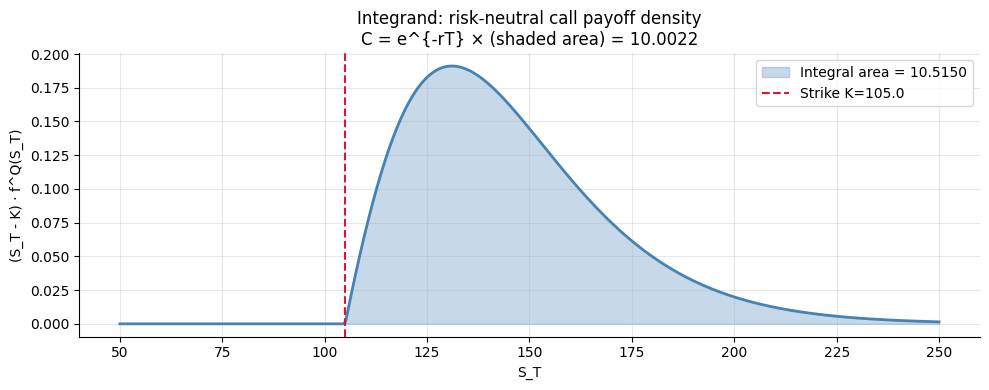

In [28]:
# Deriving the Black-Scholes formula as an integral
# C = e^{-rT} ∫_K^∞ (S_T - K) f^Q(S_T) dS_T
# Under Q: ln(S_T) ~ N(ln(S₀) + (r - σ²/2)T, σ²T)

S0_bs, K_bs, r_bs, sigma_bs, T_bs = 100.0, 105.0, 0.05, 0.25, 1.0

# Risk-neutral parameters of log(S_T)
mu_lnS = math.log(S0_bs) + (r_bs - 0.5 * sigma_bs**2) * T_bs
std_lnS = sigma_bs * math.sqrt(T_bs)


def integrand(S_T: float) -> float:
    """Risk-neutral expected payoff density: (S_T - K) * f^Q(S_T)."""
    if S_T <= 0:
        return 0.0
    payoff = max(S_T - K_bs, 0.0)
    ln_S_T = math.log(S_T)
    density = stats.norm.pdf(ln_S_T, loc=mu_lnS, scale=std_lnS) / S_T
    return payoff * density


# Numerical integration
integral_val, int_err = integrate.quad(integrand, K_bs, S0_bs * 10)
C_integral = math.exp(-r_bs * T_bs) * integral_val

# Closed-form Black-Scholes
C_bs = bs_call(S0_bs, K_bs, r_bs, sigma_bs, T_bs)

print("Option price as a risk-neutral expectation integral")
print(f"  Numerical integration: {C_integral:.6f}")
print(f"  Black-Scholes formula: {C_bs:.6f}")
print(f"  Error: {abs(C_integral - C_bs):.2e}")

# Visualise the integrand
S_T_range = np.linspace(50, 250, 400)
integrand_vals = np.array([integrand(s) for s in S_T_range])

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(S_T_range, integrand_vals, color="steelblue", linewidth=2)
ax.fill_between(
    S_T_range[S_T_range >= K_bs],
    integrand_vals[S_T_range >= K_bs],
    alpha=0.3,
    color="steelblue",
    label=f"Integral area = {integral_val:.4f}",
)
ax.axvline(K_bs, color="crimson", linestyle="--", label=f"Strike K={K_bs}")
ax.set_xlabel("S_T")
ax.set_ylabel("(S_T - K) · f^Q(S_T)")
ax.set_title(
    f"Integrand: risk-neutral call payoff density\nC = e^{{-rT}} × (shaded area) = {C_integral:.4f}"
)
ax.legend()
plt.tight_layout()
plt.show()

---
## 7  Numerical Differentiation and Integration

### 7.1  Finite differences

When no closed form exists, approximate derivatives numerically:

| Scheme | Formula | Error order |
|---|---|---|
| Forward | $(f(x+h) - f(x))/h$ | $O(h)$ |
| Backward | $(f(x) - f(x-h))/h$ | $O(h)$ |
| Central | $(f(x+h) - f(x-h))/(2h)$ | $O(h^2)$ |
| Second derivative | $(f(x+h) - 2f(x) + f(x-h))/h^2$ | $O(h^2)$ |

**Choosing $h$:** too large → truncation error; too small → floating-point cancellation. Optimal is around $h \approx \sqrt{\varepsilon_{\text{mach}}} \approx 10^{-8}$ for central differences on float64.

### 7.2  Numerical quadrature

`scipy.integrate.quad` uses adaptive Gauss-Kronrod — production quality for smooth 1D integrals.

For multi-dimensional integrals (e.g., basket option pricing), Monte Carlo integration is standard:

$$\int f(\mathbf{x})\,d\mathbf{x} \approx \frac{1}{N} \sum_{i=1}^N f(\mathbf{x}_i), \qquad \mathbf{x}_i \sim p(\mathbf{x})$$

Convergence rate: $O(1/\sqrt{N})$ independent of dimension — unlike grid-based methods which scale as $O(N^{-k/d})$.

In [29]:
# Finite difference Greeks: compute all BS Greeks numerically and compare to analytical
S_fd, K_fd, r_fd, sigma_fd, T_fd = 100.0, 100.0, 0.05, 0.20, 1.0
h_s = 0.01  # bump in S
h_sigma = 1e-4  # bump in σ
h_t = 1 / 365  # bump in t (one day)
h_r = 1e-4  # bump in r

V0_fd = bs_call(S_fd, K_fd, r_fd, sigma_fd, T_fd)

# Numerical Greeks
delta_num = (
    bs_call(S_fd + h_s, K_fd, r_fd, sigma_fd, T_fd)
    - bs_call(S_fd - h_s, K_fd, r_fd, sigma_fd, T_fd)
) / (2 * h_s)
gamma_num = (
    bs_call(S_fd + h_s, K_fd, r_fd, sigma_fd, T_fd)
    - 2 * V0_fd
    + bs_call(S_fd - h_s, K_fd, r_fd, sigma_fd, T_fd)
) / h_s**2
vega_num = (
    bs_call(S_fd, K_fd, r_fd, sigma_fd + h_sigma, T_fd)
    - bs_call(S_fd, K_fd, r_fd, sigma_fd - h_sigma, T_fd)
) / (2 * h_sigma)
theta_num = (
    bs_call(S_fd, K_fd, r_fd, sigma_fd, T_fd - h_t)
    - bs_call(S_fd, K_fd, r_fd, sigma_fd, T_fd + h_t)
) / (2 * h_t)
rho_num = (
    bs_call(S_fd, K_fd, r_fd + h_r, sigma_fd, T_fd)
    - bs_call(S_fd, K_fd, r_fd - h_r, sigma_fd, T_fd)
) / (2 * h_r)

# Analytical Greeks
d1_fd = (math.log(S_fd / K_fd) + (r_fd + 0.5 * sigma_fd**2) * T_fd) / (sigma_fd * math.sqrt(T_fd))
d2_fd = d1_fd - sigma_fd * math.sqrt(T_fd)

delta_an = stats.norm.cdf(d1_fd)
gamma_an = stats.norm.pdf(d1_fd) / (S_fd * sigma_fd * math.sqrt(T_fd))
vega_an = S_fd * stats.norm.pdf(d1_fd) * math.sqrt(T_fd)  # per unit σ
theta_an = -(S_fd * stats.norm.pdf(d1_fd) * sigma_fd) / (
    2 * math.sqrt(T_fd)
) - r_fd * K_fd * math.exp(-r_fd * T_fd) * stats.norm.cdf(d2_fd)
rho_an = K_fd * T_fd * math.exp(-r_fd * T_fd) * stats.norm.cdf(d2_fd)

print(f"{'Greek':>8}  {'Numerical':>12}  {'Analytical':>12}  {'Rel error':>12}")
print("-" * 50)
for name, num, an in [
    ("Delta", delta_num, delta_an),
    ("Gamma", gamma_num, gamma_an),
    ("Vega", vega_num, vega_an),
    ("Theta", theta_num, theta_an),
    ("Rho", rho_num, rho_an),
]:
    rel_err = abs(num - an) / (abs(an) + 1e-12)
    print(f"{name:>8}  {num:>12.6f}  {an:>12.6f}  {rel_err:>12.2e}")

   Greek     Numerical    Analytical     Rel error
--------------------------------------------------
   Delta      0.636831      0.636831      1.35e-08
   Gamma      0.018762      0.018762      1.43e-08
    Vega     37.524034     37.524035      8.11e-09
   Theta     -6.414031     -6.414028      5.81e-07
     Rho     53.232481     53.232482      1.45e-08


2-Asset Basket Call — Monte Carlo
  Price:  8.0870
  95% CI: [8.0500, 8.1240]
  StdErr: 0.0189  (O(1/√N) with N=500,000)



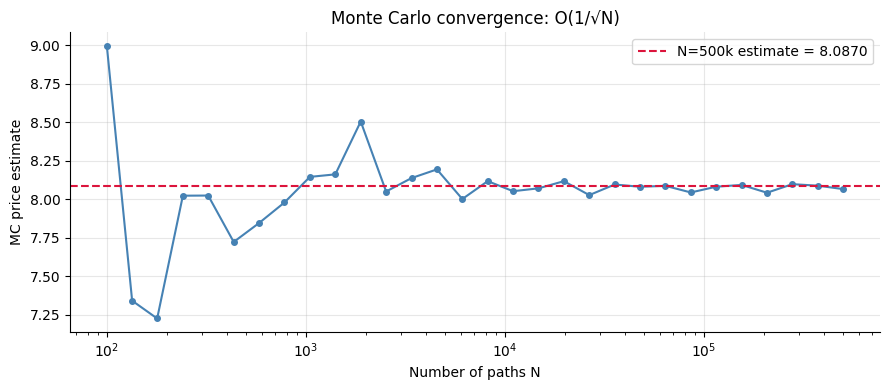

In [30]:
# Monte Carlo integration: basket option (2-asset, correlated)
# Payoff = max(0.5*S1_T + 0.5*S2_T - K, 0)  — equally weighted basket
S1_0 = S2_0 = 100.0
K_basket = 105.0
r_basket, sigma1, sigma2, rho_basket, T_basket = 0.05, 0.20, 0.25, 0.60, 1.0

# Correlated GBM: draw two correlated normals
cov_basket = (
    np.array(
        [
            [sigma1**2, rho_basket * sigma1 * sigma2],
            [rho_basket * sigma1 * sigma2, sigma2**2],
        ]
    )
    * T_basket
)
L_basket = np.linalg.cholesky(cov_basket)

n_paths = 500_000
Z_basket = rng.standard_normal((n_paths, 2)) @ L_basket.T

mu_basket = np.array(
    [
        math.log(S1_0) + (r_basket - 0.5 * sigma1**2) * T_basket,
        math.log(S2_0) + (r_basket - 0.5 * sigma2**2) * T_basket,
    ]
)

S_T = np.exp(mu_basket + Z_basket)  # n_paths × 2
basket_T = 0.5 * S_T[:, 0] + 0.5 * S_T[:, 1]
payoffs = np.maximum(basket_T - K_basket, 0.0)
C_mc = math.exp(-r_basket * T_basket) * payoffs.mean()
mc_stderr = math.exp(-r_basket * T_basket) * payoffs.std() / math.sqrt(n_paths)

print("2-Asset Basket Call — Monte Carlo")
print(f"  Price:  {C_mc:.4f}")
print(f"  95% CI: [{C_mc - 1.96 * mc_stderr:.4f}, {C_mc + 1.96 * mc_stderr:.4f}]")
print(f"  StdErr: {mc_stderr:.4f}  (O(1/√N) with N={n_paths:,})")
print()

# Compare convergence: N vs error
n_vals = np.logspace(2, 5.7, 30).astype(int)
mc_prices = []
for n in n_vals:
    Z_ = rng.standard_normal((n, 2)) @ L_basket.T
    S_ = np.exp(mu_basket + Z_)
    payoffs_ = np.maximum(0.5 * S_[:, 0] + 0.5 * S_[:, 1] - K_basket, 0)
    mc_prices.append(math.exp(-r_basket * T_basket) * payoffs_.mean())

fig, ax = plt.subplots(figsize=(9, 4))
ax.semilogx(n_vals, mc_prices, "o-", color="steelblue", markersize=4)
ax.axhline(C_mc, color="crimson", linestyle="--", label=f"N=500k estimate = {C_mc:.4f}")
ax.set_xlabel("Number of paths N")
ax.set_ylabel("MC price estimate")
ax.set_title("Monte Carlo convergence: O(1/√N)")
ax.legend()
plt.tight_layout()
plt.show()

---
## 8  Finance Applications — Deriving the Black-Scholes Formula

### 8.1  The Black-Scholes PDE (preview of Itô's Lemma)

Under GBM ($dS = \mu S\,dt + \sigma S\,dW$), Itô's Lemma gives the dynamics of any smooth $V(S, t)$:

$$dV = \underbrace{\frac{\partial V}{\partial t}}_{\Theta} dt + \underbrace{\frac{\partial V}{\partial S}}_{\Delta} dS + \frac{1}{2}\underbrace{\frac{\partial^2 V}{\partial S^2}}_{\Gamma} (dS)^2$$

The $(dS)^2 = \sigma^2 S^2 dt$ term (Itô correction) is the stochastic chain rule — differential calculus does not vanish here. A delta-neutral portfolio $\Pi = V - \Delta S$ eliminates the $dW$ term. Setting $d\Pi = r\Pi\,dt$ (no-arbitrage) gives the **Black-Scholes PDE**:

$$\frac{\partial V}{\partial t} + rS\frac{\partial V}{\partial S} + \frac{1}{2}\sigma^2 S^2 \frac{\partial^2 V}{\partial S^2} = rV$$

### 8.2  Closed-form solution — the integral evaluated

Solving the PDE (equivalently, evaluating the risk-neutral expectation integral):

$$C(S, t) = S\,N(d_1) - K e^{-r(T-t)}\,N(d_2)$$

$$d_1 = \frac{\ln(S/K) + (r + \sigma^2/2)(T-t)}{\sigma\sqrt{T-t}}, \qquad d_2 = d_1 - \sigma\sqrt{T-t}$$

$N(d_1)$ is **Delta**: the CDF of the standard normal evaluated at $d_1$ — itself an integral. Every term is a derivative or an integral.

In [31]:
# Full Black-Scholes implementation with all Greeks
from dataclasses import dataclass


@dataclass(slots=True)
class BSResult:
    price: float
    delta: float
    gamma: float
    vega: float  # per 1% move in σ
    theta: float  # per calendar day
    rho: float  # per 1% move in r
    d1: float
    d2: float


def black_scholes(
    S: float, K: float, r: float, sigma: float, T: float, option_type: str = "call"
) -> BSResult:
    d_1 = (math.log(S / K) + (r + 0.5 * sigma**2) * T) / (sigma * math.sqrt(T))
    d_2 = d_1 - sigma * math.sqrt(T)
    Nd1, Nd2 = stats.norm.cdf(d_1), stats.norm.cdf(d_2)
    nd1 = stats.norm.pdf(d_1)
    disc = math.exp(-r * T)

    match option_type:
        case "call":
            price = S * Nd1 - K * disc * Nd2
            delta = Nd1
            rho = K * T * disc * Nd2 / 100
            theta = (-(S * nd1 * sigma) / (2 * math.sqrt(T)) - r * K * disc * Nd2) / 365
        case "put":
            price = K * disc * (1 - Nd2) - S * (1 - Nd1)
            delta = Nd1 - 1
            rho = -K * T * disc * (1 - Nd2) / 100
            theta = (-(S * nd1 * sigma) / (2 * math.sqrt(T)) + r * K * disc * (1 - Nd2)) / 365
        case _:
            raise ValueError(f"Unknown option type: {option_type}")

    gamma = nd1 / (S * sigma * math.sqrt(T))
    vega = S * nd1 * math.sqrt(T) / 100  # per 1 vol point

    return BSResult(
        price=price, delta=delta, gamma=gamma, vega=vega, theta=theta, rho=rho, d1=d_1, d2=d_2
    )


# ATM call example
res = black_scholes(S=100, K=100, r=0.05, sigma=0.20, T=1.0, option_type="call")
print("ATM Call — S=100, K=100, r=5%, σ=20%, T=1yr")
print(f"  Price  : {res.price:.4f}")
print(f"  Delta  : {res.delta:.4f}  (= N(d₁) = N({res.d1:.4f}))")
print(f"  Gamma  : {res.gamma:.6f}")
print(f"  Vega   : {res.vega:.4f}  per 1 vol pt")
print(f"  Theta  : {res.theta:.4f}  per day")
print(f"  Rho    : {res.rho:.4f}  per 1% in r")

ATM Call — S=100, K=100, r=5%, σ=20%, T=1yr
  Price  : 10.4506
  Delta  : 0.6368  (= N(d₁) = N(0.3500))
  Gamma  : 0.018762
  Vega   : 0.3752  per 1 vol pt
  Theta  : -0.0176  per day
  Rho    : 0.5323  per 1% in r


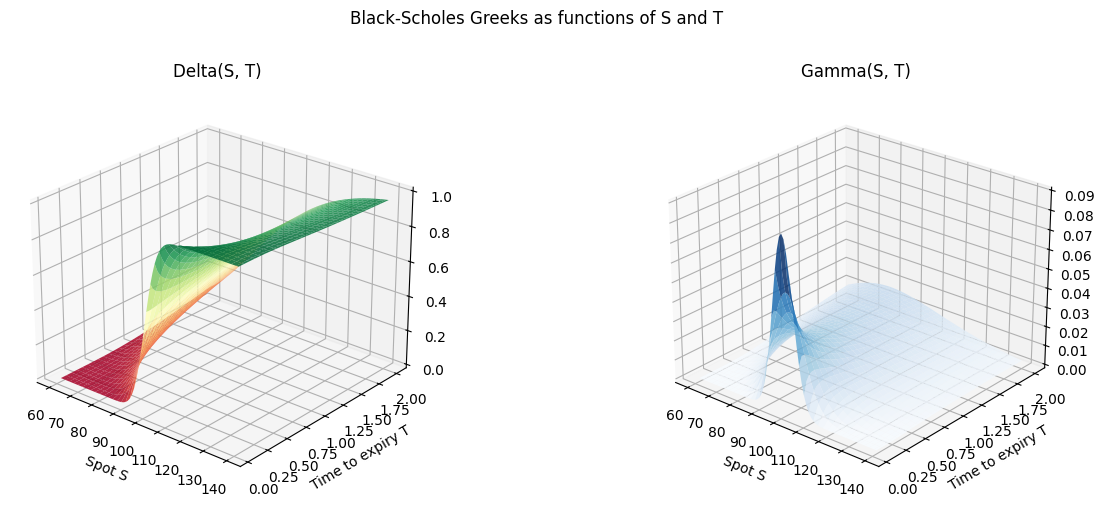

In [32]:
# Greeks surface: how each Greek varies with S and T
S_range = np.linspace(60, 140, 80)
T_range = np.linspace(0.05, 2.0, 60)
SS, TT = np.meshgrid(S_range, T_range)

K_surf, r_surf, sigma_surf = 100.0, 0.05, 0.20

Delta_surf = np.array(
    [[bs_delta(s, K_surf, r_surf, sigma_surf, t) for s in S_range] for t in T_range]
)
Gamma_surf = np.array(
    [[bs_gamma(s, K_surf, r_surf, sigma_surf, t) for s in S_range] for t in T_range]
)

fig, axes = plt.subplots(1, 2, figsize=(14, 5), subplot_kw={"projection": "3d"})

for ax, Z_surf, greek, cmap in [
    (axes[0], Delta_surf, "Delta", "RdYlGn"),
    (axes[1], Gamma_surf, "Gamma", "Blues"),
]:
    ax.plot_surface(SS, TT, Z_surf, cmap=cmap, alpha=0.85, linewidth=0)
    ax.set_xlabel("Spot S")
    ax.set_ylabel("Time to expiry T")
    ax.set_title(f"{greek}(S, T)")
    ax.view_init(elev=25, azim=-50)

plt.suptitle("Black-Scholes Greeks as functions of S and T", y=1.01)
plt.tight_layout()
plt.show()

IV round-trip max error: 7.72e-11


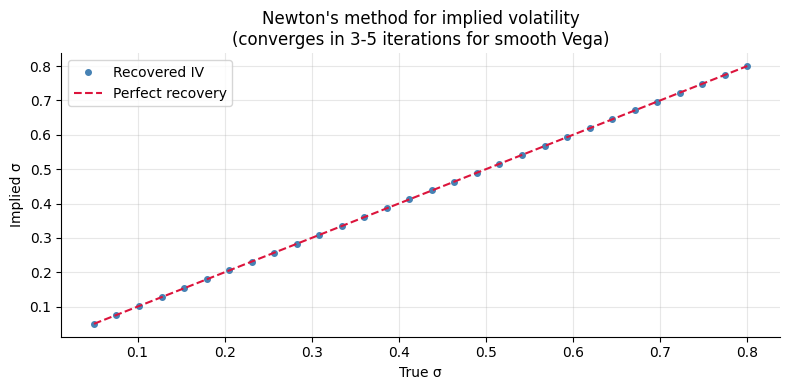

In [33]:
# Implied volatility: inverting BS by root-finding  (∂C/∂σ = Vega → Newton's method)
def implied_vol_newton(
    C_market: float,
    S: float,
    K: float,
    r: float,
    T: float,
    max_iter: int = 50,
    tol: float = 1e-8,
) -> float:
    sigma = 0.20  # initial guess (ATM approx)
    for _ in range(max_iter):
        res = black_scholes(S, K, r, sigma, T)
        diff = res.price - C_market
        if abs(diff) < tol:
            break
        vega_full = res.vega * 100  # convert back from per-point to per-unit
        if abs(vega_full) < 1e-12:
            break
        sigma -= diff / vega_full  # Newton step: σ_{n+1} = σ_n - f/f'
    return sigma


# Verify round-trip: compute BS price → recover σ
true_sigmas = np.linspace(0.05, 0.80, 30)
recovered = []
for sig in true_sigmas:
    price = bs_call(100, 100, 0.05, sig, 1.0)
    iv = implied_vol_newton(price, 100, 100, 0.05, 1.0)
    recovered.append(iv)

recovered = np.array(recovered)
print(f"IV round-trip max error: {np.abs(recovered - true_sigmas).max():.2e}")

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(true_sigmas, recovered, "o", color="steelblue", markersize=4, label="Recovered IV")
ax.plot(true_sigmas, true_sigmas, "--", color="crimson", label="Perfect recovery")
ax.set_xlabel("True σ")
ax.set_ylabel("Implied σ")
ax.set_title(
    "Newton's method for implied volatility\n(converges in 3-5 iterations for smooth Vega)"
)
ax.legend()
plt.tight_layout()
plt.show()

---
## Summary

| Concept | Formula | Where it shows up |
|---|---|---|
| Derivative (limit def.) | $f'(x) = \lim_{h\to0}(f(x+h)-f(x))/h$ | Finite-difference Greeks |
| Chain rule | $dy/dx = (dy/du)(du/dx)$ | Vega via $\partial V/\partial\sigma = \partial V/\partial d_1 \cdot \partial d_1/\partial\sigma$ |
| Total differential | $dV = \Delta dS + \mathcal{V}d\sigma + \Theta dt$ | Daily P&L attribution |
| Taylor (2nd order) | $f(x+h)\approx f + f'h + \tfrac{1}{2}f''h^2$ | Delta-Gamma approx, duration+convexity |
| Gradient | $\nabla_\mathbf{w}(\mathbf{w}^\top\Sigma\mathbf{w}) = 2\Sigma\mathbf{w}$ | Marginal risk contribution |
| Lagrangian | $\mathcal{L} = \mathbf{w}^\top\Sigma\mathbf{w} - \lambda(\mathbf{1}^\top\mathbf{w}-1)$ | Min-variance portfolio FOC |
| Definite integral | $\int_a^b f(x)dx = F(b)-F(a)$ | Fundamental Theorem |
| Risk-neutral pricing | $C = e^{-rT}E^\mathbb{Q}[\max(S_T-K,0)]$ | Option price as integral |
| Black-Scholes | $S N(d_1) - Ke^{-rT}N(d_2)$ | Closed-form integral solution |
| Newton root-finding | $\sigma_{n+1} = \sigma_n - (C_{BS}-C_{mkt})/\text{Vega}$ | Implied volatility |